<a href="https://colab.research.google.com/github/SergeiVKalinin/MSE_Spring_2026/blob/main/Module%204/22_PI_DeepONet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Physics Informed Deep Neural Operators
- Based on: https://towardsdatascience.com/operator-learning-via-physics-informed-deeponet-lets-implement-it-from-scratch-6659f3179887/
- Code at: https://github.com/ShuaiGuo16/PI-DeepONet/tree/main

### Objective

In this notebook, we develop a PI-DeepONet model that allows inputting external forcing term. Specifically, we investigate the following example equation:

\begin{equation}
\frac{ds(t)}{dt} = u(t), \; t \in [0, 1]
\end{equation}

with an initial condition $s(0)=0$.

### 0. Import libraries

In [1]:
# !pip install keras==2.14.0 tensorflow==2.14.0

In [2]:
# =========================
# Imports
# =========================

# Standard library
from pathlib import Path
import time
from collections import defaultdict

# Core scientific stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

# Notebook utilities
from tqdm.auto import tqdm

# TensorFlow / Keras
import tensorflow as tf
keras = tf.keras

# =========================
# Reproducibility
# =========================
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

### 1. Data generation

We use a zero-mean Gaussian Process to generate the dataset for both training and testing.

In [3]:
def create_samples(length_scale, sample_num, num_points=100, domain=(0.0, 1.0), seed=None):
    """
    Generate synthetic function samples u(x) from a Gaussian process prior.

    Parameters
    ----------
    length_scale : float
        Length scale of the RBF kernel.
    sample_num : int
        Number of function samples to generate.
    num_points : int, optional
        Number of discretization points in the input domain.
    domain : tuple of float, optional
        Interval over which the functions are sampled.
    seed : int or None, optional
        Random seed for reproducibility.

    Returns
    -------
    u_samples : np.ndarray of shape (sample_num, num_points)
        Sampled function values.
    """
    x_grid = np.linspace(domain[0], domain[1], num_points).reshape(-1, 1)
    kernel = RBF(length_scale=length_scale)
    gp = GaussianProcessRegressor(kernel=kernel)

    rng = np.random.default_rng(seed)
    u_samples = np.empty((sample_num, num_points), dtype=np.float64)

    for i in range(sample_num):
        sample_seed = int(rng.integers(0, 1_000_000_000))
        u_samples[i] = gp.sample_y(x_grid, random_state=sample_seed).ravel()

    return u_samples

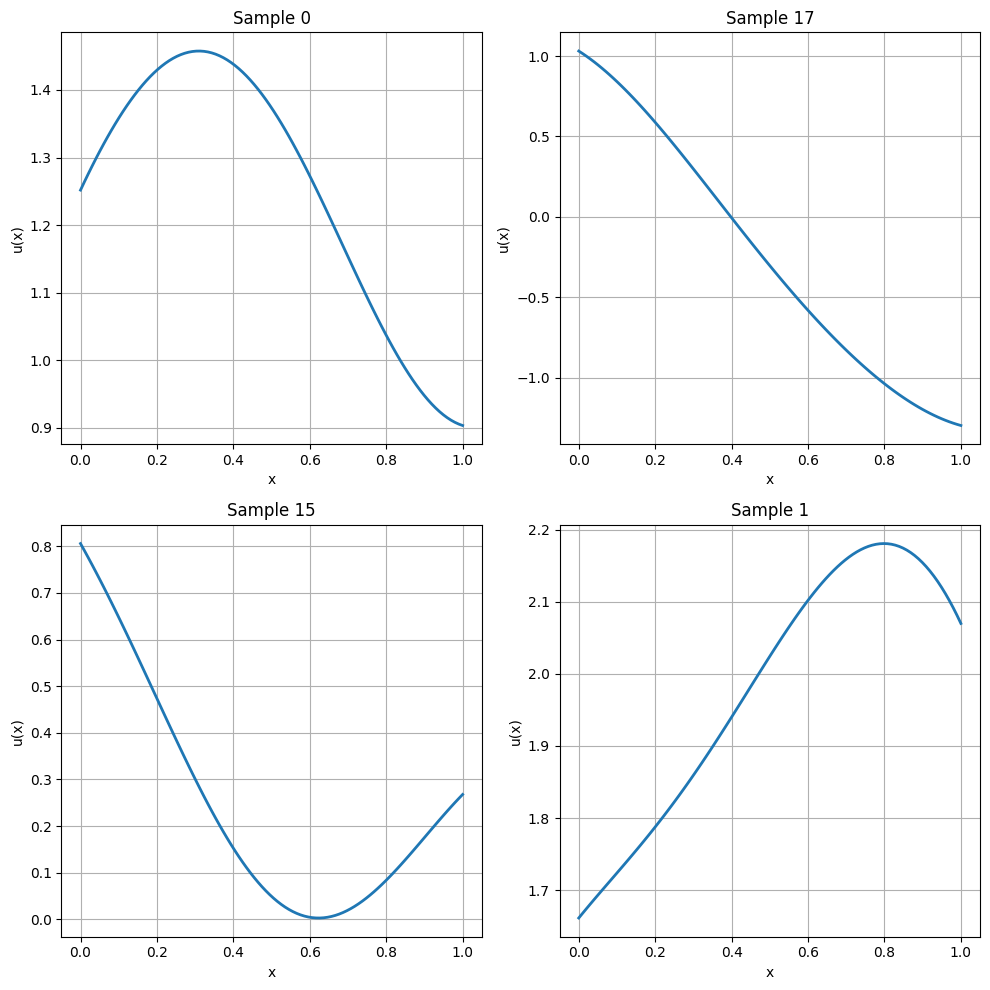

In [4]:
# Inspect generated samples
length_scale = 0.6
num_samples = 20
num_points = 100

x_grid = np.linspace(0.0, 1.0, num_points).reshape(-1, 1)
u_samples = create_samples(length_scale=length_scale, sample_num=num_samples, num_points=num_points, seed=42)

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

sample_indices = np.random.choice(num_samples, size=4, replace=False)
for ax, idx in zip(axes.flat, sample_indices):
    ax.plot(x_grid, u_samples[idx], linewidth=2)
    ax.set_xlabel("x")
    ax.set_ylabel("u(x)")
    ax.set_title(f"Sample {idx}")
    ax.grid(True)

plt.tight_layout()
plt.show()

### 2. Organize dataset for PI-DeepONet

In [5]:
def generate_dataset(num_samples, length_scale, solve_ode=False, num_points=100, domain=(0.0, 1.0), seed=None):
    """
    Generate a dataset for physics-informed DeepONet training.

    Parameters
    ----------
    num_samples : int
        Number of input functions u(x) to generate.
    length_scale : float
        Length scale of the RBF kernel used for Gaussian process sampling.
    solve_ode : bool, optional
        If True, solve the corresponding ODE to generate targets.
    num_points : int, optional
        Number of discretization points in the domain.
    domain : tuple of float, optional
        Interval over which the functions are sampled.
    seed : int or None, optional
        Random seed for reproducibility.

    Returns
    -------
    X : np.ndarray of shape (num_samples * num_points, num_points + 2)
        Input matrix containing:
        [t, u(·), u(t)].
    y : np.ndarray of shape (num_samples * num_points, 1)
        Target ODE solutions s(t). If solve_ode=False, returns zeros.
    """
    x_grid = np.linspace(domain[0], domain[1], num_points)
    u_profiles = create_samples(
        length_scale=length_scale,
        sample_num=num_samples,
        num_points=num_points,
        domain=domain,
        seed=seed,
    )

    X = np.zeros((num_samples * num_points, num_points + 2), dtype=np.float64)
    y = np.zeros((num_samples * num_points, 1), dtype=np.float64)

    for i in tqdm(range(num_samples), desc="Generating dataset"):
        profile = u_profiles[i]                              # shape: (num_points,)
        t = x_grid.reshape(-1, 1)                            # shape: (num_points, 1)
        u_repeated = np.tile(profile, (num_points, 1))       # shape: (num_points, num_points)
        u_at_t = profile.reshape(-1, 1)                      # shape: (num_points, 1)

        start = i * num_points
        stop = (i + 1) * num_points

        X[start:stop] = np.concatenate([t, u_repeated, u_at_t], axis=1)

        if solve_ode:
            sol = solve_ivp(
                fun=lambda current_t, current_s: np.interp(current_t, x_grid, profile),
                t_span=(domain[0], domain[1]),
                y0=[0.0],
                t_eval=x_grid,
                method="RK45",
            )
            y[start:stop] = sol.y[0].reshape(-1, 1)

    return X, y

In [6]:
# Dataset sizes
num_train = 2000
num_val = 100
num_test = 100

# Gaussian process settings
length_scale = 0.4

# Create training dataset
X_train, y_train = generate_dataset(
    num_samples=num_train,
    length_scale=length_scale,
    solve_ode=False,
    seed=42,
)

# Create validation dataset
X_val, y_val = generate_dataset(
    num_samples=num_val,
    length_scale=length_scale,
    solve_ode=False,
    seed=43,
)

# Create test dataset
X_test, y_test = generate_dataset(
    num_samples=num_test,
    length_scale=length_scale,
    solve_ode=True,
    seed=44,
)

Generating dataset:   0%|          | 0/2000 [00:00<?, ?it/s]

Generating dataset:   0%|          | 0/100 [00:00<?, ?it/s]

Generating dataset:   0%|          | 0/100 [00:00<?, ?it/s]

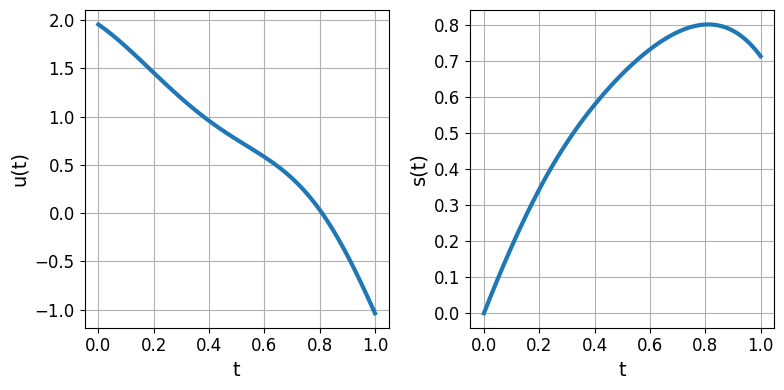

In [7]:
# Inspect one test example
sample_index = 25
num_points = X_test.shape[1] - 2
t_grid = np.linspace(0.0, 1.0, num_points)

start = sample_index * num_points
stop = (sample_index + 1) * num_points

u_profile = X_test[start, 1:-1]
s_profile = y_test[start:stop, 0]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].plot(t_grid, u_profile, linewidth=3)
axes[0].set_xlabel("t", fontsize=14)
axes[0].set_ylabel("u(t)", fontsize=14)
axes[0].tick_params(axis="both", which="major", labelsize=12)
axes[0].grid(True)

axes[1].plot(t_grid, s_profile, linewidth=3)
axes[1].set_xlabel("t", fontsize=14)
axes[1].set_ylabel("s(t)", fontsize=14)
axes[1].tick_params(axis="both", which="major", labelsize=12)
axes[1].grid(True)

plt.tight_layout()
plt.show()

#### Separate initial condition and collocation points

In [8]:
# Batch sizes
num_points = X_train.shape[1] - 2
num_train_samples = X_train.shape[0] // num_points

initial_batch_size = max(1, num_train_samples // 100)
collocation_batch_size = 2000

# Initial-condition subset: rows with t = 0
initial_mask = np.isclose(X_train[:, 0], 0.0)
X_train_initial = X_train[initial_mask].astype(np.float32)

initial_ds = tf.data.Dataset.from_tensor_slices(X_train_initial)
initial_ds = initial_ds.shuffle(len(X_train_initial), seed=SEED).batch(initial_batch_size)

# Full collocation dataset
X_train_tensor = tf.convert_to_tensor(X_train, dtype=tf.float32)

train_ds = tf.data.Dataset.from_tensor_slices(X_train_tensor)
train_ds = train_ds.shuffle(len(X_train), seed=SEED).batch(collocation_batch_size)

# Input scaling statistics
scaling_mean = {
    "forcing": X_train[:, 1:-1].mean(axis=0),
    "time": X_train[:, :1].mean(axis=0),
}

scaling_var = {
    "forcing": X_train[:, 1:-1].var(axis=0),
    "time": X_train[:, :1].var(axis=0),
}

### 3. Physics-informed DeepONet

#### Define a custom layer for adding a bias

In [9]:
class BiasLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        self.bias = self.add_weight(
            name="bias",
            shape=(1,),
            initializer="zeros",
            trainable=True,
        )
        super().build(input_shape)

    def call(self, inputs):
        return inputs + self.bias

#### Define Physics-informed DeepONet

In [10]:
def create_model(mean, var, verbose=False):
    """
    Build a DeepONet model with fully connected branch and trunk networks.

    Parameters
    ----------
    mean : dict
        Dictionary with input means for normalization.
        Expected keys: "forcing", "time".
    var : dict
        Dictionary with input variances for normalization.
        Expected keys: "forcing", "time".
    verbose : bool, optional
        If True, print the model summary.

    Returns
    -------
    model : tf.keras.Model
        DeepONet model.
    """
    forcing_dim = len(mean["forcing"])
    time_dim = len(mean["time"])

    # Small epsilon for numerical stability in normalization
    forcing_var = np.asarray(var["forcing"], dtype=np.float32) + 1e-8
    time_var = np.asarray(var["time"], dtype=np.float32) + 1e-8

    forcing_mean = np.asarray(mean["forcing"], dtype=np.float32)
    time_mean = np.asarray(mean["time"], dtype=np.float32)

    # Branch network
    branch_input = tf.keras.Input(shape=(forcing_dim,), name="forcing")
    branch = tf.keras.layers.Normalization(
        mean=forcing_mean,
        variance=forcing_var,
        name="branch_normalization",
    )(branch_input)

    for i in range(3):
        branch = tf.keras.layers.Dense(
            50,
            activation="tanh",
            name=f"branch_dense_{i + 1}",
        )(branch)

    # Trunk network
    trunk_input = tf.keras.Input(shape=(time_dim,), name="time")
    trunk = tf.keras.layers.Normalization(
        mean=time_mean,
        variance=time_var,
        name="trunk_normalization",
    )(trunk_input)

    for i in range(3):
        trunk = tf.keras.layers.Dense(
            50,
            activation="tanh",
            name=f"trunk_dense_{i + 1}",
        )(trunk)

    # Elementwise product + reduction over feature dimension
    merged = tf.keras.layers.Multiply(name="branch_trunk_product")([branch, trunk])
    dot_product = tf.keras.layers.Lambda(
        lambda x: tf.reduce_sum(x, axis=1, keepdims=True),
        name="dot_product",
    )(merged)

    # Add scalar trainable bias
    output = BiasLayer(name="output_bias")(dot_product)

    model = tf.keras.Model(
        inputs=[branch_input, trunk_input],
        outputs=output,
        name="DeepONet",
    )

    if verbose:
        model.summary()

    return model

#### ODE loss

In [11]:
@tf.function
def compute_ode_residual(t, forcing, forcing_at_t, model):
    """
    Compute the ODE residual:
        ds/dt - u(t)

    Parameters
    ----------
    t : tf.Tensor
        Time coordinates with shape (batch_size, 1).
    forcing : tf.Tensor
        Discretized input function u(·) with shape (batch_size, num_points).
    forcing_at_t : tf.Tensor
        Input function evaluated at t, with shape (batch_size, 1).
    model : tf.keras.Model
        DeepONet model.

    Returns
    -------
    residual : tf.Tensor
        ODE residual with shape (batch_size, 1).
    """
    t = tf.cast(t, tf.float32)
    forcing = tf.cast(forcing, tf.float32)
    forcing_at_t = tf.cast(forcing_at_t, tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(t)
        s = model({"forcing": forcing, "time": t}, training=True)

    ds_dt = tape.gradient(s, t)
    residual = ds_dt - forcing_at_t

    return residual

#### Gradient descent step

In [12]:
@tf.function
def train_step(X, X_init, ic_weight, ode_weight, model):
    """
    Compute physics-informed losses and gradients for one training step.

    Parameters
    ----------
    X : tf.Tensor
        Collocation batch with columns [t, u(·), u(t)].
    X_init : tf.Tensor
        Initial-condition batch with the same column structure.
    ic_weight : float or tf.Tensor
        Weight for the initial-condition loss.
    ode_weight : float or tf.Tensor
        Weight for the ODE residual loss.
    model : tf.keras.Model
        DeepONet model.

    Returns
    -------
    ode_loss : tf.Tensor
        Mean squared ODE residual loss.
    ic_loss : tf.Tensor
        Mean squared initial-condition loss.
    total_loss : tf.Tensor
        Weighted sum of losses.
    gradients : list[tf.Tensor]
        Gradients of total_loss with respect to model parameters.
    """
    X = tf.cast(X, tf.float32)
    X_init = tf.cast(X_init, tf.float32)
    ic_weight = tf.cast(ic_weight, tf.float32)
    ode_weight = tf.cast(ode_weight, tf.float32)

    with tf.GradientTape() as tape:
        # Initial condition prediction: s(0) should be 0
        s_init_pred = model(
            {
                "forcing": X_init[:, 1:-1],
                "time": X_init[:, :1],
            },
            training=True,
        )

        # ODE residual: ds/dt - u(t)
        ode_residual = compute_ode_residual(
            t=X[:, :1],
            forcing=X[:, 1:-1],
            forcing_at_t=X[:, -1:],
            model=model,
        )

        ic_loss = tf.reduce_mean(tf.square(s_init_pred))
        ode_loss = tf.reduce_mean(tf.square(ode_residual))
        total_loss = ic_weight * ic_loss + ode_weight * ode_loss

    gradients = tape.gradient(total_loss, model.trainable_variables)

    return ode_loss, ic_loss, total_loss, gradients

#### Define Loss Tracking class

In [13]:
class LossTracking:
    def __init__(self):
        self.mean_total_loss = keras.metrics.Mean(name="total_loss")
        self.mean_ic_loss = keras.metrics.Mean(name="ic_loss")
        self.mean_ode_loss = keras.metrics.Mean(name="ode_loss")
        self.loss_history = defaultdict(list)

    def update(self, total_loss, ic_loss, ode_loss):
        self.mean_total_loss.update_state(total_loss)
        self.mean_ic_loss.update_state(ic_loss)
        self.mean_ode_loss.update_state(ode_loss)

    def reset(self):
        self.mean_total_loss.reset_state()
        self.mean_ic_loss.reset_state()
        self.mean_ode_loss.reset_state()

    def print(self):
        print(
            f"IC={self.mean_ic_loss.result().numpy():.4e}, "
            f"ODE={self.mean_ode_loss.result().numpy():.4e}, "
            f"total_loss={self.mean_total_loss.result().numpy():.4e}"
        )

    def history(self):
        self.loss_history["total_loss"].append(self.mean_total_loss.result().numpy())
        self.loss_history["IC_loss"].append(self.mean_ic_loss.result().numpy())
        self.loss_history["ODE_loss"].append(self.mean_ode_loss.result().numpy())

#### Training

In [14]:
# Training configuration
num_epochs = 300
ic_weight = tf.constant(1.0, dtype=tf.float32)
ode_weight = tf.constant(1.0, dtype=tf.float32)

loss_tracker = LossTracking()
validation_loss_history = []
predicted_profiles = []

optimizer = keras.optimizers.Adam(learning_rate=1e-3)

# Build model
pi_deeponet = create_model(scaling_mean, scaling_var)
pi_deeponet.compile(optimizer=optimizer)

# Callbacks
callback_list = keras.callbacks.CallbackList(
    [
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=30,
            verbose=1,
        ),
        keras.callbacks.ModelCheckpoint(
            filepath="nn_model.keras",
            monitor="val_loss",
            save_best_only=True,
            verbose=0,
        ),
    ],
    add_history=False,
    model=pi_deeponet,
)

callback_list.on_train_begin()

# Validation initial-condition subset
X_val_initial = X_val[np.isclose(X_val[:, 0], 0.0)]

# Useful dimensions
num_points = X_test.shape[1] - 2
sample_index = 25
sample_start = sample_index * num_points
sample_stop = (sample_index + 1) * num_points

# Training loop
for epoch in range(1, num_epochs + 1):
    print(f"Epoch {epoch}")

    for X_init_batch, X_batch in zip(initial_ds, train_ds):
        ode_loss, ic_loss, total_loss, gradients = train_step(
            X=X_batch,
            X_init=X_init_batch,
            ic_weight=ic_weight,
            ode_weight=ode_weight,
            model=pi_deeponet,
        )

        pi_deeponet.optimizer.apply_gradients(
            zip(gradients, pi_deeponet.trainable_variables)
        )

        loss_tracker.update(total_loss, ic_loss, ode_loss)

    # Training loss summary
    loss_tracker.history()
    loss_tracker.print()
    loss_tracker.reset()

    # Validation: ODE residual
    val_residual = compute_ode_residual(
        t=X_val[:, :1],
        forcing=X_val[:, 1:-1],
        forcing_at_t=X_val[:, -1:],
        model=pi_deeponet,
    )
    val_ode_loss = tf.reduce_mean(tf.square(val_residual))

    # Validation: initial condition s(0) = 0
    val_init_pred = pi_deeponet.predict(
        {
            "forcing": X_val_initial[:, 1:-1],
            "time": X_val_initial[:, :1],
        },
        batch_size=8192,
        verbose=0,
    )
    val_ic_loss = tf.reduce_mean(tf.square(val_init_pred))

    val_loss = val_ic_loss + val_ode_loss
    validation_loss_history.append(float(val_loss.numpy()))

    current_lr = float(tf.keras.backend.get_value(pi_deeponet.optimizer.learning_rate))
    print(
        f"val_IC: {val_ic_loss.numpy():.4e}, "
        f"val_ODE: {val_ode_loss.numpy():.4e}, "
        f"lr: {current_lr:.2e}"
    )

    callback_list.on_epoch_end(epoch, logs={"val_loss": float(val_loss.numpy())})

    # Test prediction and RMSE
    pred_test = pi_deeponet.predict(
        {
            "forcing": X_test[:, 1:-1],
            "time": X_test[:, :1],
        },
        batch_size=8192,
        verbose=0,
    )
    test_rmse = np.sqrt(mean_squared_error(y_test.ravel(), pred_test.ravel()))
    print(f"Test RMSE: {test_rmse:.6e}")

    # Store one sample profile prediction
    pred_profile = pi_deeponet.predict(
        {
            "forcing": X_test[sample_start:sample_stop, 1:-1],
            "time": X_test[sample_start:sample_stop, :1],
        },
        batch_size=8192,
        verbose=0,
    )
    predicted_profiles.append(pred_profile)

callback_list.on_train_end()

Epoch 1
IC=7.3385e-02, ODE=3.4933e-01, total_loss=4.2272e-01
val_IC: 7.6252e-03, val_ODE: 6.3970e-02, lr: 1.00e-03
Test RMSE: 1.322617e-01
Epoch 2
IC=5.1298e-03, ODE=4.5451e-02, total_loss=5.0580e-02
val_IC: 3.7865e-03, val_ODE: 3.3563e-02, lr: 1.00e-03
Test RMSE: 7.857235e-02
Epoch 3
IC=2.6099e-03, ODE=3.0361e-02, total_loss=3.2971e-02
val_IC: 1.7238e-03, val_ODE: 2.4556e-02, lr: 1.00e-03
Test RMSE: 5.347498e-02
Epoch 4
IC=1.5568e-03, ODE=2.2729e-02, total_loss=2.4286e-02
val_IC: 1.1097e-03, val_ODE: 1.8858e-02, lr: 1.00e-03
Test RMSE: 4.134434e-02
Epoch 5
IC=1.0651e-03, ODE=1.7676e-02, total_loss=1.8741e-02
val_IC: 8.3922e-04, val_ODE: 1.5391e-02, lr: 1.00e-03
Test RMSE: 3.467894e-02
Epoch 6
IC=7.1956e-04, ODE=1.4534e-02, total_loss=1.5254e-02
val_IC: 7.1346e-04, val_ODE: 1.3329e-02, lr: 1.00e-03
Test RMSE: 2.982719e-02
Epoch 7
IC=5.1428e-04, ODE=1.2727e-02, total_loss=1.3241e-02
val_IC: 4.9251e-04, val_ODE: 1.2179e-02, lr: 1.00e-03
Test RMSE: 2.751726e-02
Epoch 8
IC=3.6464e-04, ODE=

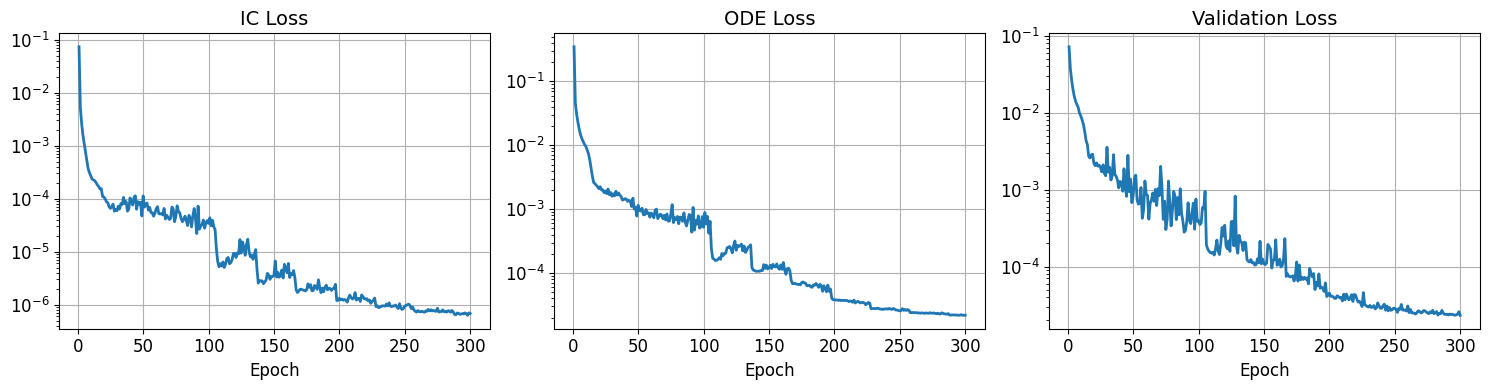

In [15]:
# Training history
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ic_history = loss_tracker.loss_history["IC_loss"]
ode_history = loss_tracker.loss_history["ODE_loss"]
val_history = validation_loss_history
epochs = np.arange(1, len(ic_history) + 1)

axes[0].plot(epochs, ic_history, linewidth=2)
axes[1].plot(epochs, ode_history, linewidth=2)
axes[2].plot(epochs, val_history, linewidth=2)

axes[0].set_title("IC Loss", fontsize=14)
axes[1].set_title("ODE Loss", fontsize=14)
axes[2].set_title("Validation Loss", fontsize=14)

for ax in axes:
    ax.set_xlabel("Epoch", fontsize=12)
    ax.set_yscale("log")
    ax.tick_params(axis="both", which="major", labelsize=12)
    ax.grid(True)

plt.tight_layout()
plt.savefig("loss.png", bbox_inches="tight", pad_inches=0, transparent=True)
plt.show()

#### Inspect accuracy on test set

In [16]:
# Recreate the model
pi_deeponet = create_model(scaling_mean, scaling_var)

# Load the best saved weights
pi_deeponet.load_weights("nn_model.keras")

In [17]:
# Make predictions on the test set
pred_test = pi_deeponet.predict(
    {
        "forcing": X_test[:, 1:-1],
        "time": X_test[:, :1],
    },
    batch_size=8192,
    verbose=0,
)

# Overall accuracy
test_rmse = np.sqrt(mean_squared_error(y_test.ravel(), pred_test.ravel()))
print(f"RMSE: {test_rmse:.4e}")

RMSE: 1.7690e-03


#### Convergence display

In [18]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Animation settings
sample_index = 25
num_points = X_test.shape[1] - 2
t_grid = np.linspace(0.0, 1.0, num_points)

start = sample_index * num_points
stop = (sample_index + 1) * num_points
true_profile = y_test[start:stop, 0]

# Create figure
fig, ax = plt.subplots(figsize=(8, 4))

def init():
    ax.clear()
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(-0.15, 0.15)
    ax.set_xlabel("t", fontsize=14)
    ax.set_ylabel("s(t)", fontsize=14)
    ax.set_title("Epoch 0", fontsize=14)
    ax.tick_params(axis="both", which="major", labelsize=12)
    ax.grid(True)
    return ax.lines

def update(frame_idx):
    ax.clear()

    pred_profile = predicted_profiles[frame_idx].ravel()
    ax.plot(t_grid, pred_profile, linewidth=2, label="Prediction")
    ax.plot(t_grid, true_profile, linewidth=2, label="Ground Truth")

    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(-0.15, 0.15)
    ax.set_xlabel("t", fontsize=14)
    ax.set_ylabel("s(t)", fontsize=14)
    ax.set_title(f"Epoch {frame_idx + 1}", fontsize=14)
    ax.tick_params(axis="both", which="major", labelsize=12)
    ax.grid(True)
    ax.legend(fontsize=12)

    return ax.lines

num_saved_profiles = len(predicted_profiles)
frames = range(0, num_saved_profiles, 2)

animation = FuncAnimation(
    fig,
    update,
    frames=frames,
    init_func=init,
    blit=False,
    interval=100,
    repeat=True,
)

plt.close(fig)
HTML(animation.to_jshtml())

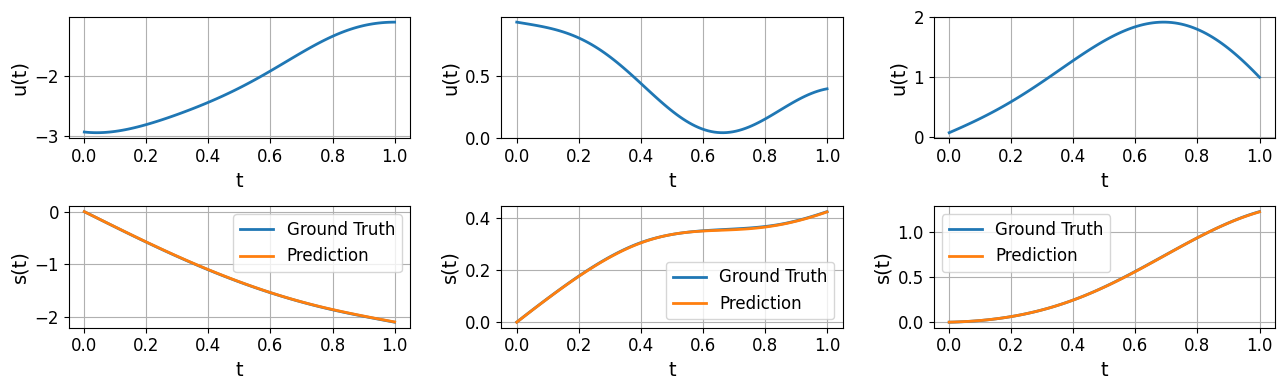

In [19]:
# Spot check on random test samples
fig, axes = plt.subplots(2, 3, figsize=(13, 4))

num_points = X_test.shape[1] - 2
num_test_samples = X_test.shape[0] // num_points
t_grid = np.linspace(0.0, 1.0, num_points)

sample_ids = np.random.choice(num_test_samples, size=3, replace=False)

for col, sample_id in enumerate(sample_ids):
    start = sample_id * num_points
    stop = (sample_id + 1) * num_points

    u_profile = X_test[start, 1:-1]
    true_profile = y_test[start:stop, 0]
    pred_profile = pred_test[start:stop, 0]

    # Input function u(t)
    axes[0, col].plot(t_grid, u_profile, linewidth=2)
    axes[0, col].set_xlabel("t", fontsize=14)
    axes[0, col].set_ylabel("u(t)", fontsize=14)
    axes[0, col].tick_params(axis="both", which="major", labelsize=12)
    axes[0, col].grid(True)

    # True vs predicted solution s(t)
    axes[1, col].plot(t_grid, true_profile, linewidth=2, label="Ground Truth")
    axes[1, col].plot(t_grid, pred_profile, linewidth=2, label="Prediction")
    axes[1, col].set_xlabel("t", fontsize=14)
    axes[1, col].set_ylabel("s(t)", fontsize=14)
    axes[1, col].tick_params(axis="both", which="major", labelsize=12)
    axes[1, col].grid(True)
    axes[1, col].legend(fontsize=12)

plt.tight_layout()
plt.savefig("testing.png", bbox_inches="tight", transparent=True)
plt.show()

#### Out-of-distribution prediction

In [20]:
# Create an additional test dataset with a different length scale
num_test = 100
test_length_scale = 0.2

X_test_shifted, y_test_shifted = generate_dataset(
    num_samples=num_test,
    length_scale=test_length_scale,
    solve_ode=True,
    seed=45,
)

Generating dataset:   0%|          | 0/100 [00:00<?, ?it/s]

In [21]:
# Make predictions on the shifted test set
pred_test_shifted = pi_deeponet.predict(
    {
        "forcing": X_test_shifted[:, 1:-1],
        "time": X_test_shifted[:, :1],
    },
    batch_size=8192,
    verbose=0,
)

# Overall accuracy
test_shifted_rmse = np.sqrt(
    mean_squared_error(y_test_shifted.ravel(), pred_test_shifted.ravel())
)
print(f"RMSE: {test_shifted_rmse:.4e}")

RMSE: 8.0900e-02


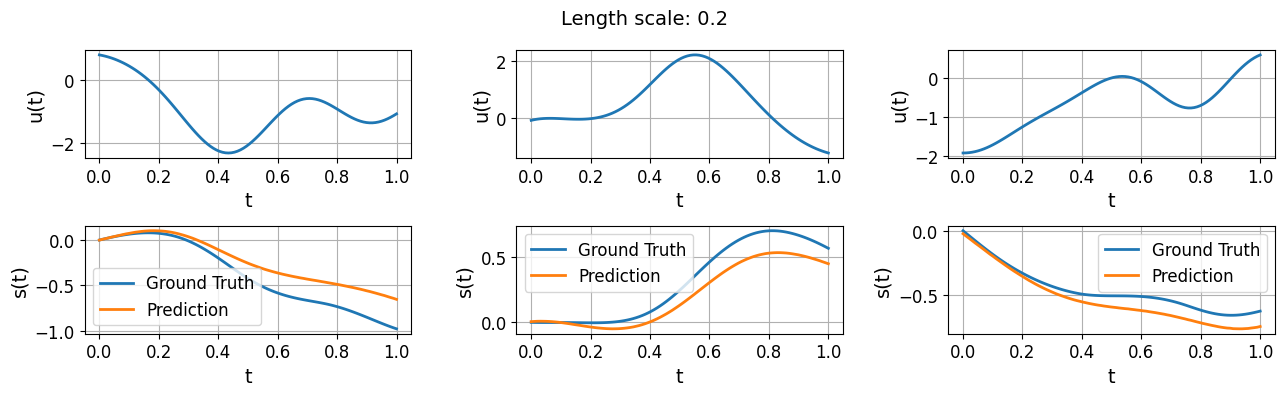

In [22]:
# Spot check on the shifted test set
fig, axes = plt.subplots(2, 3, figsize=(13, 4))

num_points = X_test_shifted.shape[1] - 2
num_test_samples = X_test_shifted.shape[0] // num_points
t_grid = np.linspace(0.0, 1.0, num_points)

sample_ids = np.random.choice(num_test_samples, size=3, replace=False)

for col, sample_id in enumerate(sample_ids):
    start = sample_id * num_points
    stop = (sample_id + 1) * num_points

    u_profile = X_test_shifted[start, 1:-1]
    true_profile = y_test_shifted[start:stop, 0]
    pred_profile = pred_test_shifted[start:stop, 0]

    axes[0, col].plot(t_grid, u_profile, linewidth=2)
    axes[0, col].set_xlabel("t", fontsize=14)
    axes[0, col].set_ylabel("u(t)", fontsize=14)
    axes[0, col].tick_params(axis="both", which="major", labelsize=12)
    axes[0, col].grid(True)

    axes[1, col].plot(t_grid, true_profile, linewidth=2, label="Ground Truth")
    axes[1, col].plot(t_grid, pred_profile, linewidth=2, label="Prediction")
    axes[1, col].set_xlabel("t", fontsize=14)
    axes[1, col].set_ylabel("s(t)", fontsize=14)
    axes[1, col].tick_params(axis="both", which="major", labelsize=12)
    axes[1, col].grid(True)
    axes[1, col].legend(fontsize=12)

fig.suptitle(f"Length scale: {test_length_scale}", fontsize=14)
plt.tight_layout()
plt.savefig("testing_ood.png", bbox_inches="tight", transparent=True)
plt.show()

#### Barplot for generalization capability

In [23]:
# Evaluate performance across different GP length scales
length_scale_list = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
rmse_list = []

num_test = 100

for test_length_scale in length_scale_list:
    # Create test dataset
    X_eval, y_eval = generate_dataset(
        num_samples=num_test,
        length_scale=test_length_scale,
        solve_ode=True,
        seed=45,
    )

    # Make prediction
    pred_eval = pi_deeponet.predict(
        {
            "forcing": X_eval[:, 1:-1],
            "time": X_eval[:, :1],
        },
        batch_size=8192,
        verbose=0,
    )

    # Store RMSE
    rmse = np.sqrt(mean_squared_error(y_eval.ravel(), pred_eval.ravel()))
    rmse_list.append(rmse)

rmse_list

Generating dataset:   0%|          | 0/100 [00:00<?, ?it/s]

Generating dataset:   0%|          | 0/100 [00:00<?, ?it/s]

Generating dataset:   0%|          | 0/100 [00:00<?, ?it/s]

Generating dataset:   0%|          | 0/100 [00:00<?, ?it/s]

Generating dataset:   0%|          | 0/100 [00:00<?, ?it/s]

Generating dataset:   0%|          | 0/100 [00:00<?, ?it/s]

Generating dataset:   0%|          | 0/100 [00:00<?, ?it/s]

[np.float64(0.32534617808061655),
 np.float64(0.08090000037564916),
 np.float64(0.010690073750382554),
 np.float64(0.0026596345960027672),
 np.float64(0.00201028968447076),
 np.float64(0.002270236651809986),
 np.float64(0.0027265889055490765)]

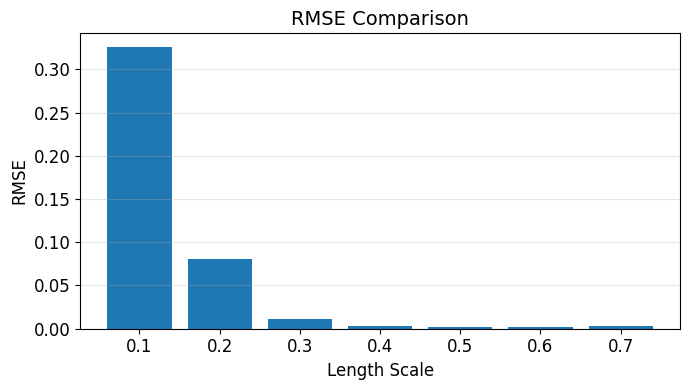

In [24]:
# RMSE as a function of GP length scale
plt.figure(figsize=(7, 4))
plt.bar(range(len(rmse_list)), rmse_list)

plt.xticks(range(len(rmse_list)), length_scale_list)
plt.xlabel("Length Scale", fontsize=12)
plt.ylabel("RMSE", fontsize=12)
plt.title("RMSE Comparison", fontsize=14)
plt.tick_params(axis="both", which="major", labelsize=12)
plt.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("testing_ood_bar.png", bbox_inches="tight", transparent=True)
plt.show()

# Example 2 - SHO